In [86]:
# import os for traversing csv files
import os

# import pandas and numpy for math and data processing
import pandas as pd
import numpy as np

# import matplotlib and seaborn for plotting and visualizations
from matplotlib import pyplot as plt
import seaborn

# import gradient-boosted decision tree library - XGBoost
import xgboost as xgb

# import loss functions
from sklearn.metrics import brier_score_loss, mean_absolute_error

# import spline interpolation
from scipy.interpolate import UnivariateSpline

# for pagerank
from collections import defaultdict
import networkx as nx

# options to suppress irrelevant errors and comprehensive display for pandas
pd.options.mode.chained_assignment = None 
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [87]:
# Helper function: given the path of a csv file, returns a list of the columns
def col_list(csv_file):
    df = pd.read_csv(f'data/{csv_file}')
    return df.columns.tolist()

In [88]:
# display all the csv files, along with the columns of data they contain
csv_list = os.listdir('data')
csv_list.remove(".gitattributes")
for i in range(len(csv_list)):
    csv = csv_list[i]
    print(f"{i + 1}: {csv} - Columns: {col_list(csv)}")

1: MConferenceTourneyGames.csv - Columns: ['Season', 'ConfAbbrev', 'DayNum', 'WTeamID', 'LTeamID']
2: MMasseyOrdinals.csv - Columns: ['Season', 'RankingDayNum', 'SystemName', 'TeamID', 'OrdinalRank']
3: MNCAATourneyDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
4: MNCAATourneySeedRoundSlots.csv - Columns: ['Seed', 'GameRound', 'GameSlot', 'EarlyDayNum', 'LateDayNum']
5: MNCAATourneySeeds.csv - Columns: ['Season', 'Seed', 'TeamID']
6: MNCAATourneySlots.csv - Columns: ['Season', 'Slot', 'StrongSeed', 'WeakSeed']
7: MRegularSeasonDetailedResults.csv - Columns: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', '

In [89]:
# Store and display the men's and women's data files separately

mens_data = [csv for csv in csv_list if csv[0] == 'M']
womens_data = [csv for csv in csv_list if csv[0] == 'W']

print("MENS INFO:\n--------------------------")

for mf in mens_data:
    print(f"{mf[:-4]}: {col_list(mf)}")

print("\nWOMENS INFO:\n--------------------------")

for wf in womens_data:
    print(f"{wf[:-4]}: {col_list(wf)}")

MENS INFO:
--------------------------
MConferenceTourneyGames: ['Season', 'ConfAbbrev', 'DayNum', 'WTeamID', 'LTeamID']
MMasseyOrdinals: ['Season', 'RankingDayNum', 'SystemName', 'TeamID', 'OrdinalRank']
MNCAATourneyDetailedResults: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
MNCAATourneySeedRoundSlots: ['Seed', 'GameRound', 'GameSlot', 'EarlyDayNum', 'LateDayNum']
MNCAATourneySeeds: ['Season', 'Seed', 'TeamID']
MNCAATourneySlots: ['Season', 'Slot', 'StrongSeed', 'WeakSeed']
MRegularSeasonDetailedResults: ['Season', 'DayNum', 'WTeamID', 'WScore', 'LTeamID', 'LScore', 'WLoc', 'NumOT', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LA

In [90]:
# Load the men's data and save as dataframes
M_regular_season_results = pd.read_csv("data/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv("data/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv("data/MNCAATourneySeeds.csv")

In [91]:
# Display the men's regular season results - every individual game
M_regular_season_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124524,2026,132,1335,88,1463,84,N,1,29,64,14,28,16,16,11,26,17,13,5,4,16,31,71,9,24,13,17,17,24,23,9,9,4,16
124525,2026,132,1345,80,1276,72,N,0,30,57,4,14,16,22,7,22,21,2,4,5,13,30,64,7,24,5,6,11,22,15,7,2,3,18
124526,2026,132,1378,70,1455,55,N,0,23,61,6,22,18,23,14,27,13,10,10,3,20,19,56,4,19,13,20,12,27,8,14,7,7,19
124527,2026,132,1433,70,1173,62,N,0,23,57,11,24,13,19,6,28,12,5,9,4,18,23,53,7,21,9,17,8,31,16,11,3,4,18


In [92]:
# Only consider recent data by setting a start season
season = 2003 
M_regular_season_results = M_regular_season_results.loc[M_regular_season_results["Season"] >= season]
M_tourney_results = M_tourney_results.loc[M_tourney_results["Season"] >= season]
M_seeds = M_seeds.loc[M_seeds["Season"] >= season]

In [93]:
# See the data, restricted to the start season
M_regular_season_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124524,2026,132,1335,88,1463,84,N,1,29,64,14,28,16,16,11,26,17,13,5,4,16,31,71,9,24,13,17,17,24,23,9,9,4,16
124525,2026,132,1345,80,1276,72,N,0,30,57,4,14,16,22,7,22,21,2,4,5,13,30,64,7,24,5,6,11,22,15,7,2,3,18
124526,2026,132,1378,70,1455,55,N,0,23,61,6,22,18,23,14,27,13,10,10,3,20,19,56,4,19,13,20,12,27,8,14,7,7,19
124527,2026,132,1433,70,1173,62,N,0,23,57,11,24,13,19,6,28,12,5,9,4,18,23,53,7,21,9,17,8,31,16,11,3,4,18


In [94]:
# Examine the tournament results DataFrame
M_tourney_results

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,2025,146,1120,70,1277,64,N,0,26,61,7,25,11,20,10,26,16,6,4,5,16,22,64,7,23,13,16,11,27,12,9,5,5,18
1445,2025,146,1222,69,1397,50,N,0,28,66,9,25,4,4,13,27,15,3,7,4,16,15,52,5,29,15,20,11,23,12,9,3,2,9
1446,2025,152,1196,79,1120,73,N,0,25,53,8,21,21,30,12,26,7,16,7,3,15,25,57,7,25,16,23,9,20,11,12,11,3,22
1447,2025,152,1222,70,1181,67,N,0,23,61,10,22,14,18,15,23,10,8,6,6,16,21,53,7,17,18,23,10,19,14,7,7,4,16


In [95]:
# Examine the seeds DataFrame
M_seeds

,Season,Seed,TeamID
1154,2003,W01,1328
1155,2003,W02,1448
1156,2003,W03,1393
1157,2003,W04,1257
1158,2003,W05,1280
...,...,...,...
2689,2026,Z12,1219
2690,2026,Z13,1218
2691,2026,Z14,1244
2692,2026,Z15,1474


In [96]:
# helper function to visualize a specific team's season

def M_view_season(team_id, season):

    reg_res = M_regular_season_results.loc[
        (M_regular_season_results["Season"] == season)
        & ((M_regular_season_results["WTeamID"] == team_id) | (M_regular_season_results["LTeamID"] == team_id))]
    tour_res = M_tourney_results.loc[
        (M_tourney_results["Season"] == season)
        & ((M_tourney_results["WTeamID"] == team_id) | (M_tourney_results["LTeamID"] == team_id))
    ]

    reg_res["result"] = np.where(reg_res["WTeamID"] == team_id, "W", "L")
    tour_res["result"] = np.where(tour_res["WTeamID"] == team_id, "W", "L")
    reg_res["type"] = "regular season"
    tour_res["type"] = "tournament"

    summary = pd.concat([reg_res, tour_res])

    return summary[["DayNum", "WScore", "LScore", "type", "result"]]

M_view_season(team_id=1181, season=2024) # Duke, 2024 (R64: W, R32: W, R16: W, E8 - L)

,DayNum,WScore,LScore,type,result
107660,0,92,54,regular season,W
107806,4,78,73,regular season,L
107990,8,74,65,regular season,W
108108,11,90,60,regular season,W
108349,15,95,66,regular season,W
108478,18,80,62,regular season,W
108687,23,80,75,regular season,L
108832,26,72,68,regular season,L
109072,33,80,56,regular season,W
109196,36,89,68,regular season,W


In [97]:
# helper function to get a team's seed based on id and season
def M_get_seed(team_id, season):
    return M_seeds.loc[(M_seeds["Season"] == season) & (M_seeds["TeamID"] == team_id)]

M_get_seed(team_id=1181, season=2024) # Duke was a 4th seed in 2024


,Season,Seed,TeamID
2544,2024,Z04,1181


In [98]:
# helper function to prepare data by normalizing statistics for overtime and duplicate each game from
# both teams' perspectives
def prepare_data(results_df):
    
    # remove WLoc from features - Location - Home (H), Away (A), Neutral (N)
    all_but_WLoc = ["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
            "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
            "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    
    results_df = results_df[all_but_WLoc]

    # creates a column for OT adjustment factor based on NumOT column
    ot_adjust = (40 + 5 * results_df["NumOT"]) / 40

    # specify stats which need to be adjusted
    cols_adjust = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]

    # for each column that needs to be adjusted, adjust by corresponding adjustment factor
    for col in cols_adjust:
        results_df[col] = results_df[col] / ot_adjust

    # need to have a copy for each result for each team's persepctive (helpful during aggregation)
    # Use T1 and T2 for column standardization instead of W and L
    results_df_symmetric = results_df.copy()
    results_df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(results_df.columns)]
    results_df_symmetric.columns =  [x.replace("L", "T1_").replace("W", "T2_") for x in list(results_df_symmetric.columns)]

    # combine both perspective results
    combined = pd.concat([results_df, results_df_symmetric]).reset_index(drop = True)

    # add point differential for game
    combined["PointDiff"] = combined["T1_Score"] - combined["T2_Score"]

    # add indicator for win for game
    combined["win"] = (combined["PointDiff"] > 0) * 1

    return combined

M_reg_data = prepare_data(M_regular_season_results)

print("Men's Regular Season Detailed Results:")
print(M_reg_data)

M_tourney_data = prepare_data(M_tourney_results)

print("Men's Tourney Detailed Results:")
print(M_tourney_data)

Men's Regular Season Detailed Results:
        Season  DayNum  T2_TeamID   T2_Score  T1_TeamID   T1_Score  NumOT     T2_FGM     T2_FGA    T2_FGM3    T2_FGA3     T2_FTM     T2_FTA      T2_OR      T2_DR     T2_Ast      T2_TO     T2_Stl    T2_Blk      T2_PF     T1_FGM     T1_FGA  T1_FGM3    T1_FGA3     T1_FTM     T1_FTA      T1_OR      T1_DR     T1_Ast  T1_TO  T1_Stl    T1_Blk      T1_PF  PointDiff  win
0         2003      10       1328  62.000000       1104  68.000000      0  22.000000  53.000000   2.000000  10.000000  16.000000  22.000000  10.000000  22.000000   8.000000  18.000000   9.000000  2.000000  20.000000  27.000000  58.000000      3.0  14.000000  11.000000  18.000000  14.000000  24.000000  13.000000   23.0     7.0  1.000000  22.000000   6.000000    1
1         2003      10       1393  63.000000       1272  70.000000      0  24.000000  67.000000   6.000000  24.000000   9.000000  20.000000  20.000000  25.000000   7.000000  12.000000   8.000000  6.000000  16.000000  26.000000  62.

In [99]:
# Sanity check to ensure that preprocessing has worked successfully - check a specific outcome for symmetry

# helper function for aggregation - shows both team's pov (data is flipped essentially)
season = M_reg_data["Season"] == 2025
T1, T2 = 1182, 1433
match1 = (M_reg_data["T1_TeamID"] == T1) & (M_reg_data["T2_TeamID"] == T2)
match2 = (M_reg_data["T1_TeamID"] == T2) & (M_reg_data["T2_TeamID"] == T1)

M_reg_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win
118444,2025,120,1182,62.0,1433,71.0,0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,9.0,1
242973,2025,120,1433,71.0,1182,62.0,0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,-9.0,0


# Features

In [100]:
# Convert Seeds to integer
M_seeds["seed"] = M_seeds["Seed"].apply(lambda x: int(x[1:3]))
M_seeds

,Season,Seed,TeamID,seed
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5
...,...,...,...,...
2689,2026,Z12,1219,12
2690,2026,Z13,1218,13
2691,2026,Z14,1244,14
2692,2026,Z15,1474,15


In [101]:
# Join a table that displays each tournament matchup along with the:
#   - outcome, point differential, each team's seed, and the seed differential

T1_seeds = M_seeds[["Season", "TeamID", "seed"]].copy()
T2_seeds = M_seeds[["Season", "TeamID", "seed"]].copy()

T1_seeds.columns = ["Season", "T1_TeamID", "T1_seed"]
T2_seeds.columns = ["Season", "T2_TeamID", "T2_seed"]

M_tourney_data = M_tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win"]]

M_tourney_data = pd.merge(M_tourney_data, T1_seeds, on=["Season", "T1_TeamID"], how = "left")
M_tourney_data = pd.merge(M_tourney_data, T2_seeds, on=["Season", "T2_TeamID"], how = "left")

M_tourney_data["seed_Diff"] = M_tourney_data["T2_seed"] - M_tourney_data["T1_seed"]
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff
0,2003,1421,1411,7.111111,1,16,16,0
1,2003,1112,1436,29.000000,1,1,16,15
2,2003,1113,1272,13.000000,1,10,7,-3
3,2003,1141,1166,6.000000,1,11,6,-5
4,2003,1143,1301,1.777778,1,8,9,1
...,...,...,...,...,...,...,...,...
2893,2025,1277,1120,-6.000000,0,2,1,-1
2894,2025,1397,1222,-19.000000,0,2,1,-1
2895,2025,1120,1196,-6.000000,0,1,1,0
2896,2025,1181,1222,-3.000000,0,1,1,0


Text(0.5, 1.0, 'Point Differential v. Seed')

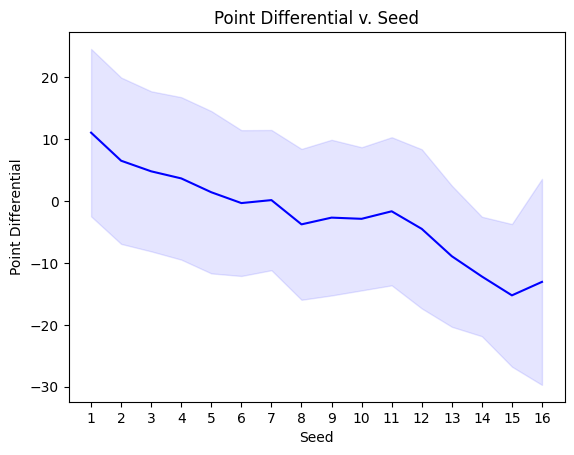

In [102]:
# Visualize how good of a metric seed is for predicting outcome
mu_seed = M_tourney_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed =  M_tourney_data.pivot_table(index = "T1_seed", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed - sigma_seed)['PointDiff'])
top = list((mu_seed + sigma_seed)['PointDiff'])

plt.plot(mu_seed.index, mu_seed, 'b-')
plt.fill_between(mu_seed.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed')
plt.ylabel('Point Differential')
plt.xticks(list(range(1,17)))
plt.title("Point Differential v. Seed")

# for across all matchups a seed plays

Text(0.5, 1.0, 'Point Differential v. Seed Differential')

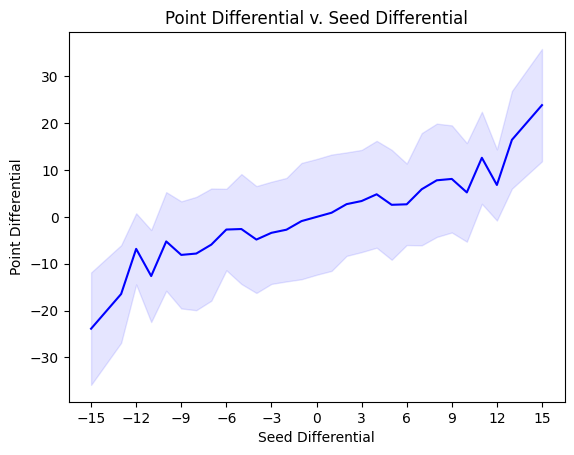

In [103]:
# Visualize how good of a metrics seed differential is for predicting outcome
mu_seed_diff = M_tourney_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "mean").ffill()
sigma_seed_diff =  M_tourney_data.pivot_table(index = "seed_Diff", values = "PointDiff", aggfunc = "std").ffill()

bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

plt.plot(mu_seed_diff.index, mu_seed_diff, 'b-')
plt.fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
plt.xlabel('Seed Differential')
plt.ylabel('Point Differential')
plt.xticks(list(range(-15,16,3)))
plt.title("Point Differential v. Seed Differential")

Reference: https://www.kaggle.com/code/raddar/vilnius-ncaa#%3C%3C--Easy-difficulty-features--%3E%3E

In [104]:
# list which stats we want to aggregate acros the season for each team 
#   - calculate all interesting features
box_score_stats = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

In [105]:
# aggregate the average statistics for every team across the season and concatenate the corresponding
# columns on the tournament matchup data
season_stats = M_reg_data.groupby(["Season", "T1_TeamID"])[box_score_stats].agg("mean").reset_index()

season_stats_T1 = season_stats.copy()
season_stats_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T1.columns)]
season_stats_T1 = season_stats_T1.rename({"T1_avg_Season" : "Season", "T1_avg_TeamID" : "T1_TeamID"}, axis = 1)

season_stats_T2 = season_stats.copy()
season_stats_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(season_stats_T2.columns)]
season_stats_T2 = season_stats_T2.rename({"T2_avg_Season" : "Season", "T2_avg_TeamID" : "T2_TeamID"}, axis = 1)

M_tourney_data = pd.merge(M_tourney_data, season_stats_T1, on = ["Season", "T1_TeamID"], how = "left")
M_tourney_data = pd.merge(M_tourney_data, season_stats_T2, on = ["Season", "T2_TeamID"], how = "left")
M_tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,T1_seed,T2_seed,seed_Diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,16.903704,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370
...,...,...,...,...

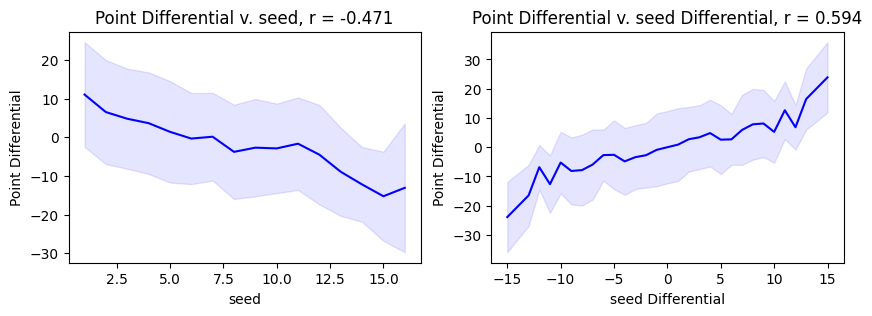

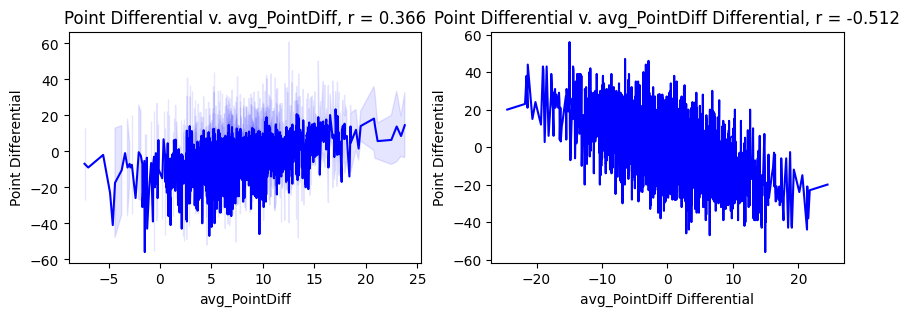

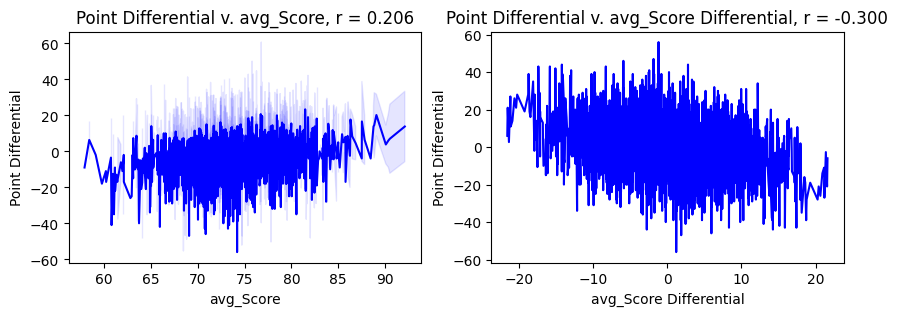

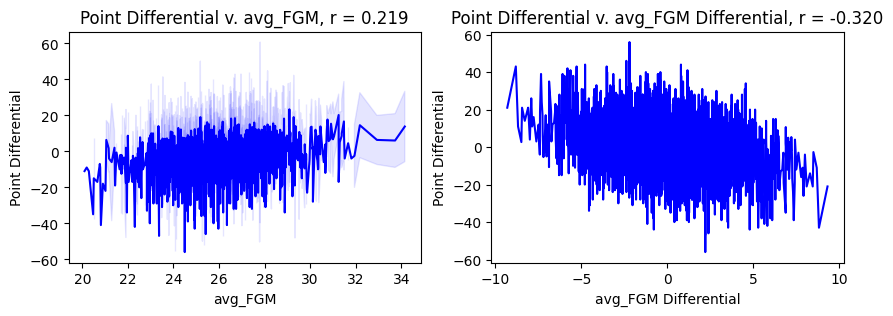

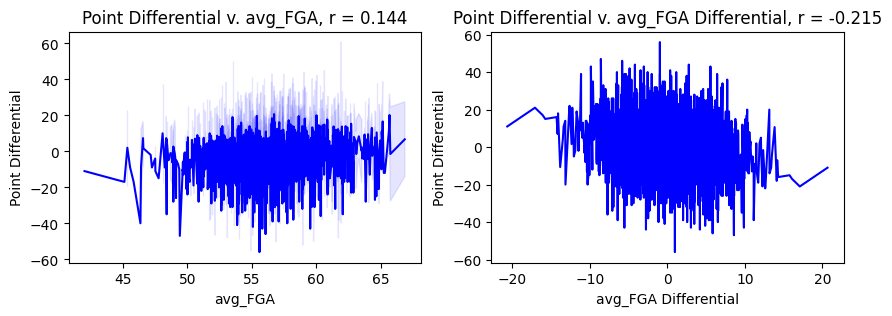

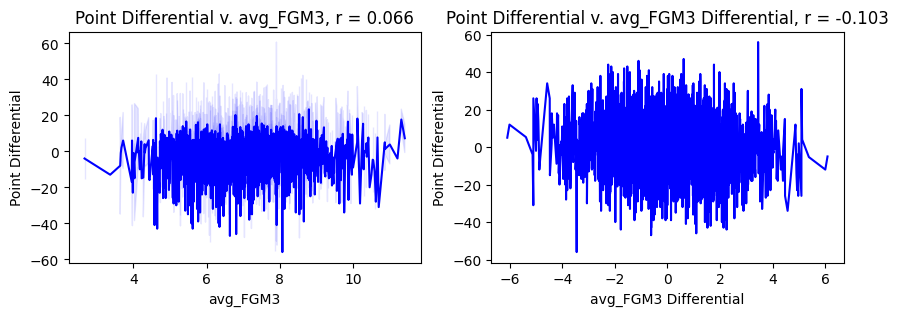

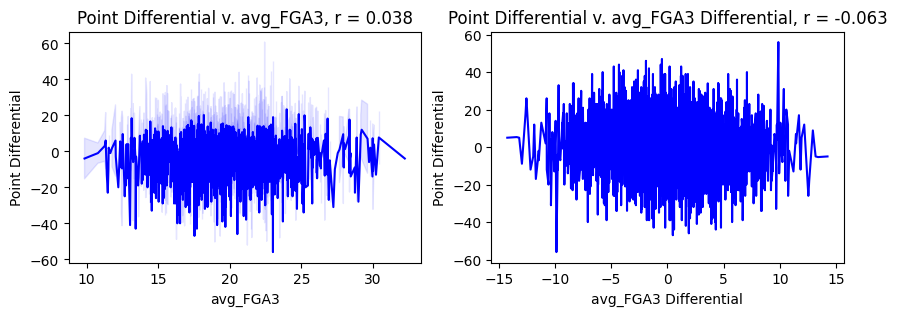

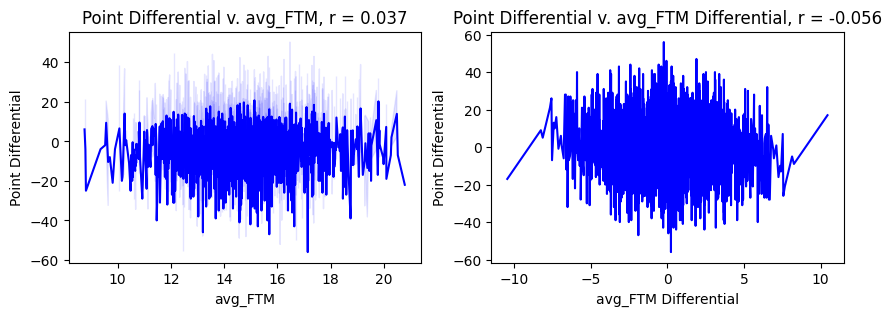

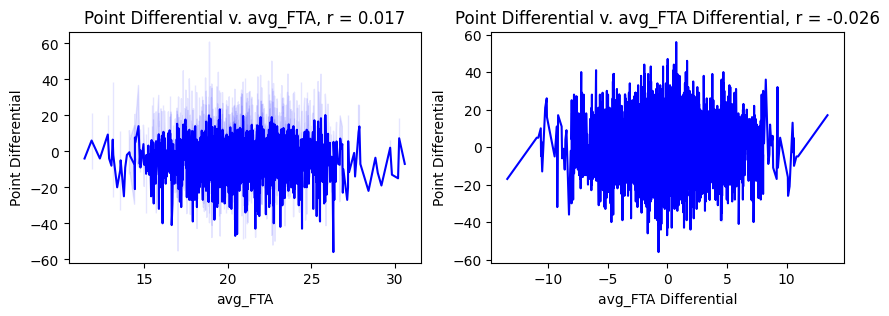

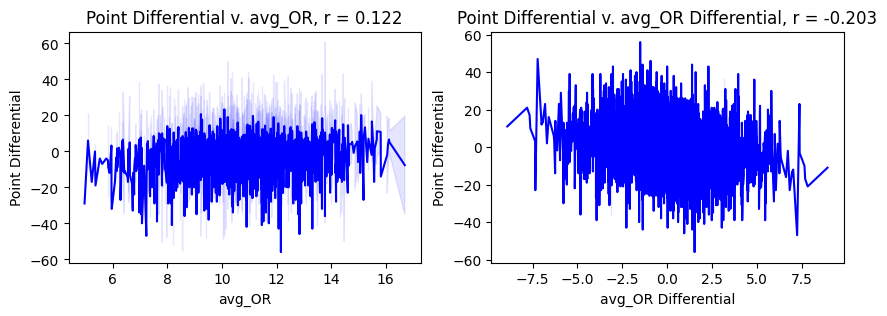

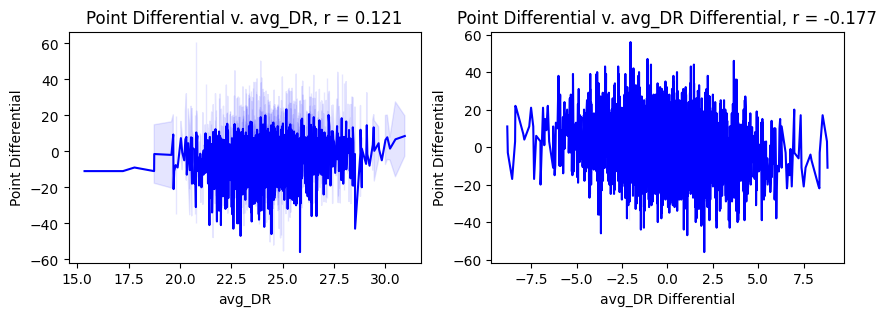

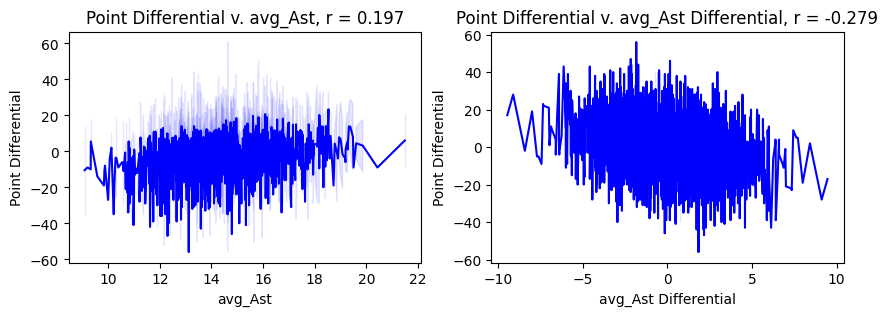

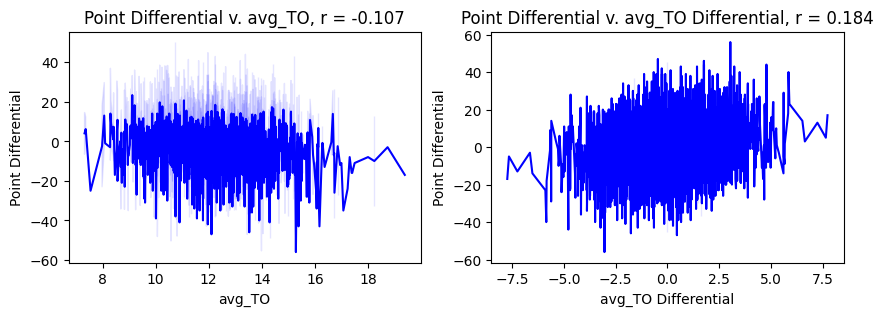

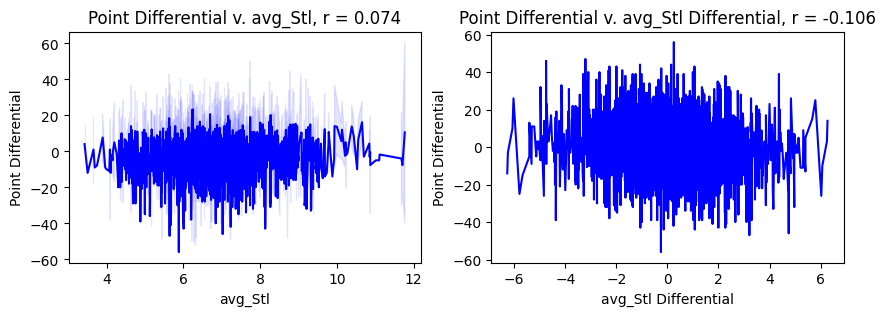

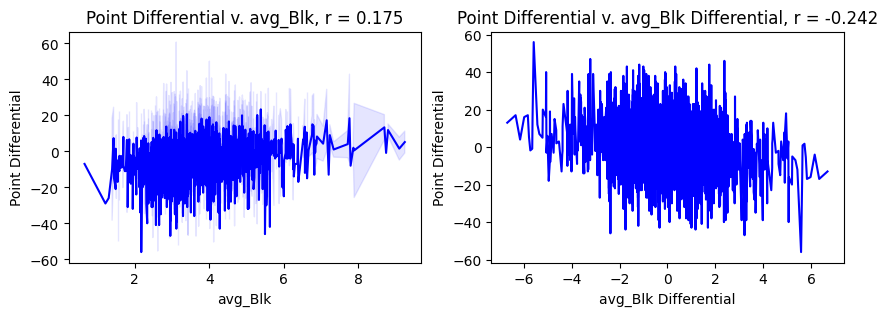

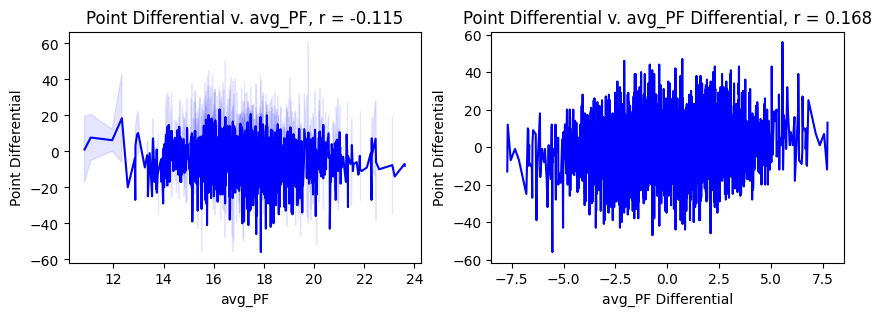

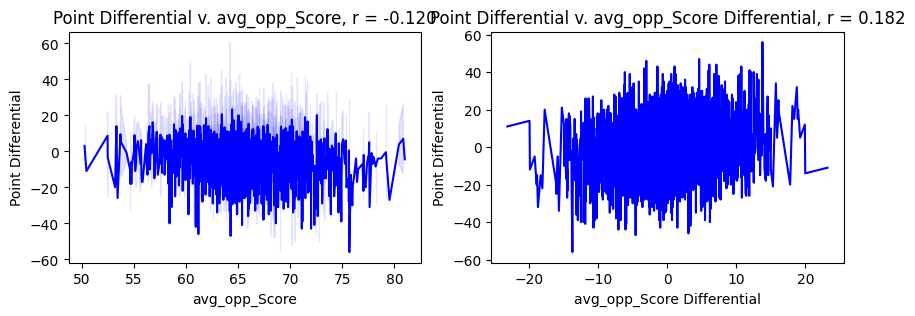

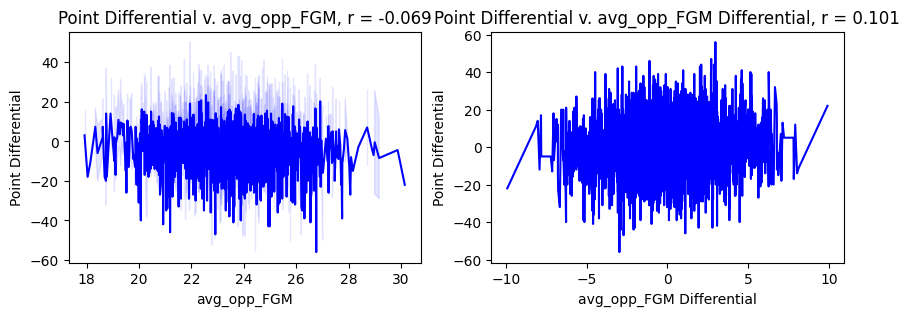

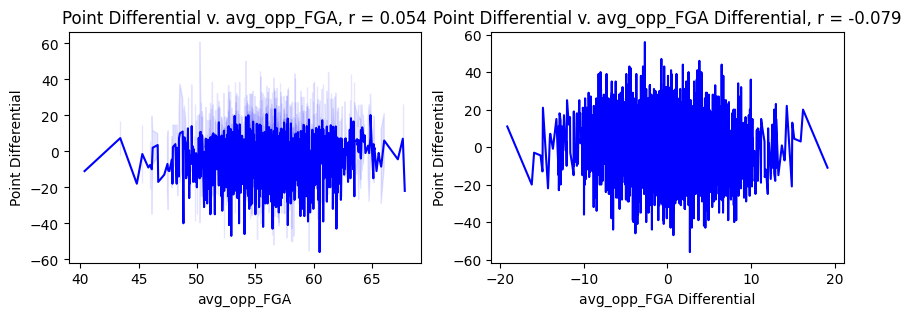

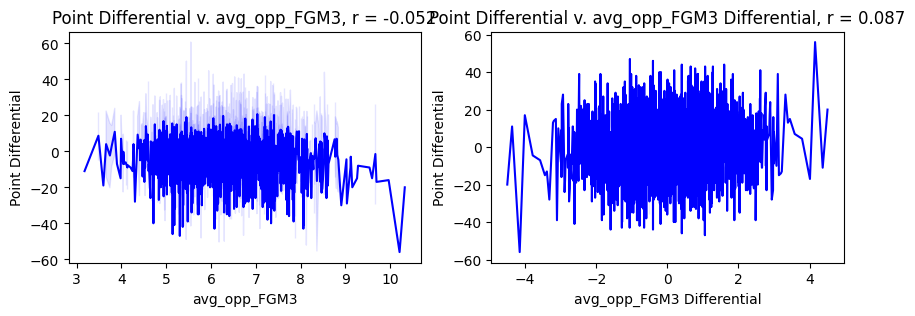

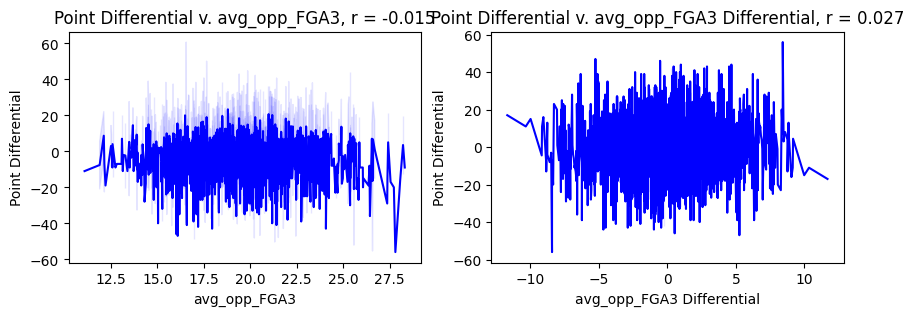

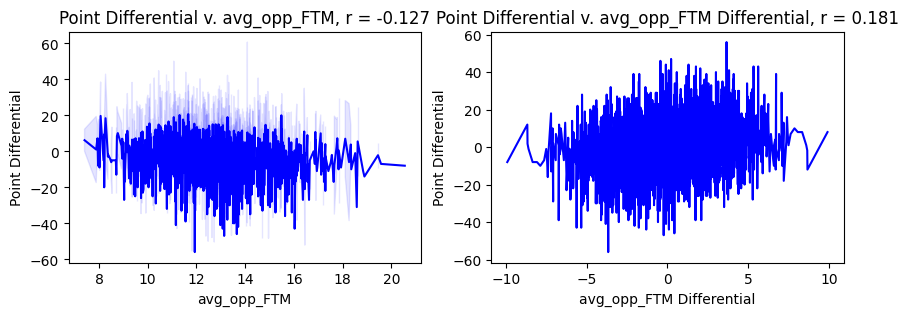

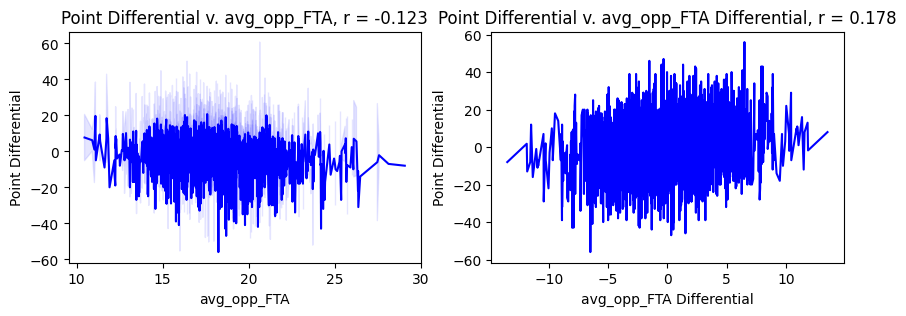

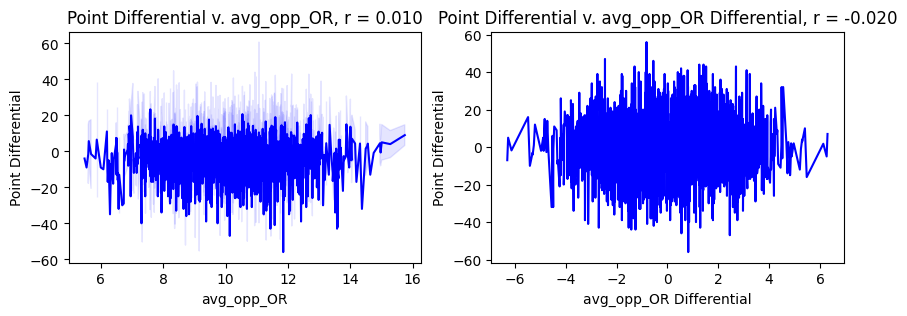

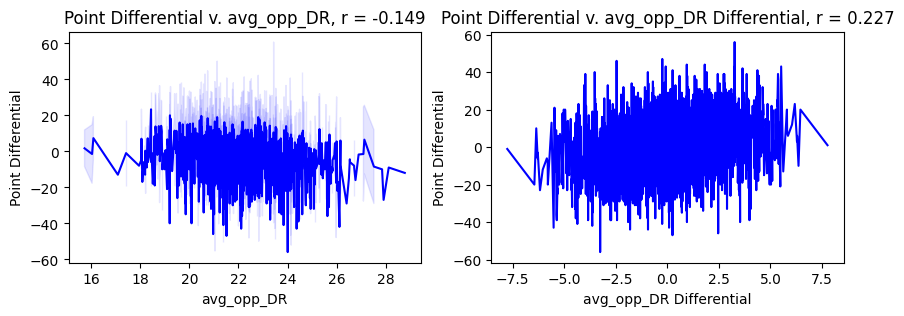

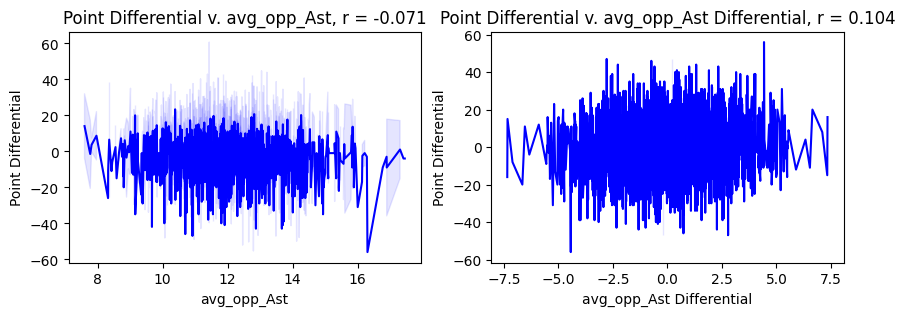

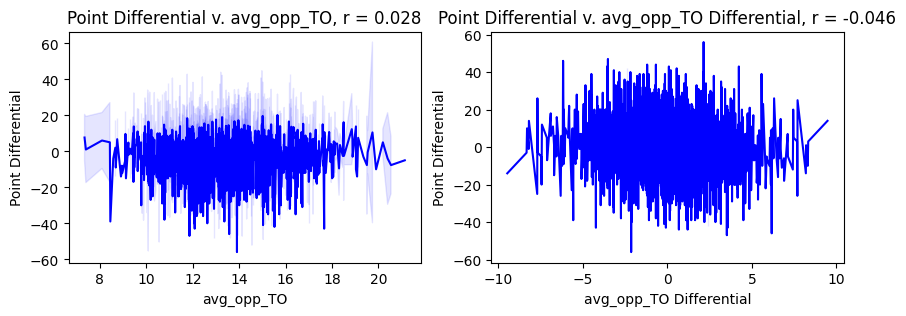

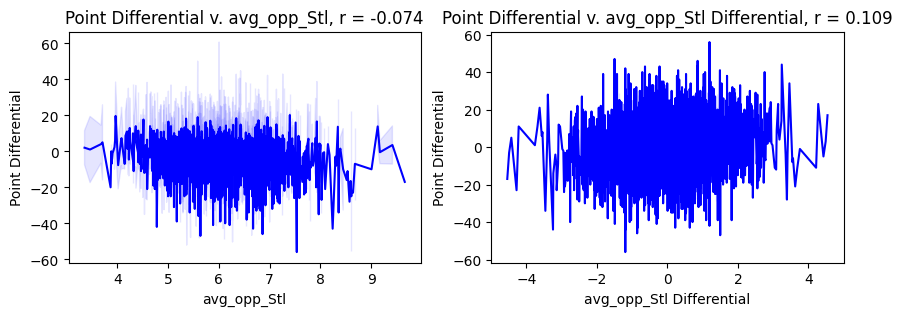

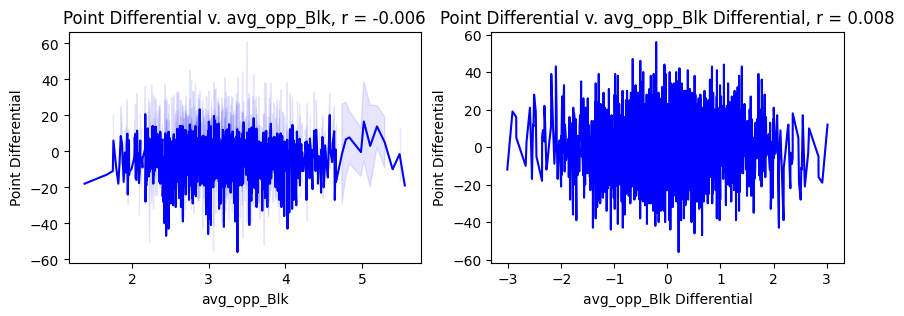

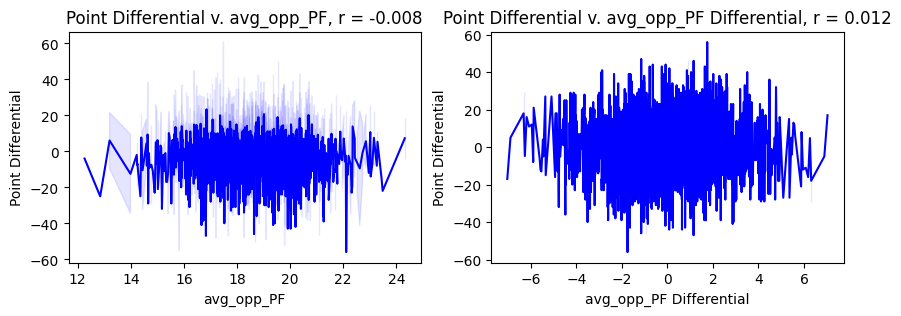

In [106]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation(stat_name, start_year = 2003):

    # Visualize how good of a metric the raw stat is for predicting outcome

    subset_tourney_data = M_tourney_data.loc[M_tourney_data["Season"] >= start_year].copy()

    corr_df = subset_tourney_data[["PointDiff", f"T1_{stat_name}"]].copy()
    r = corr_df.corr().iloc[0,1]

    mu_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_stat = subset_tourney_data.pivot_table(index = f"T1_{stat_name}", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_stat - sigma_stat)['PointDiff'])
    top = list((mu_stat + sigma_stat)['PointDiff'])

    fig, axs = plt.subplots(1, 2)
    fig.set_figheight(3)
    fig.set_figwidth(10)

    condensed_stat_name = stat_name if not "opponent" in stat_name else stat_name[:7] + stat_name[12:]

    axs[0].plot(mu_stat.index, mu_stat, 'b-')
    axs[0].fill_between(mu_stat.index,bottom, top, color="b", alpha=0.1)
    axs[0].set_xlabel(condensed_stat_name)
    axs[0].set_ylabel('Point Differential')
    axs[0].set_title(f"Point Differential v. {condensed_stat_name}, r = {r:.3f}")

    # Visualize how good of a metrics stat differential is for predicting outcome

    subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

    corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
    r_diff = corr_diff_df.corr().iloc[0,1]

    mu_seed_diff = subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "mean").ffill()
    sigma_seed_diff =  subset_tourney_data.pivot_table(index = f"{stat_name}_Diff", values = "PointDiff", aggfunc = "std").ffill()

    bottom = list((mu_seed_diff - sigma_seed_diff)['PointDiff'])
    top = list((mu_seed_diff + sigma_seed_diff)['PointDiff'])

    axs[1].plot(mu_seed_diff.index, mu_seed_diff, 'b-')
    axs[1].fill_between(mu_seed_diff.index,bottom, top, color="b", alpha=0.1)
    axs[1].set_xlabel(f'{condensed_stat_name} Differential')
    axs[1].set_ylabel('Point Differential')
    axs[1].set_title(f"Point Differential v. {condensed_stat_name} Differential, r = {r_diff:.3f}")

    plt.show()

my_stats = ["seed", "avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA", 'avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

opponent_stats = [stat[:4] + "opponent_" + stat[4:] for stat in my_stats[2:]]

for statistic in my_stats:
    visualize_stat_correlation(statistic)

for statistic in opponent_stats:
    visualize_stat_correlation(statistic)

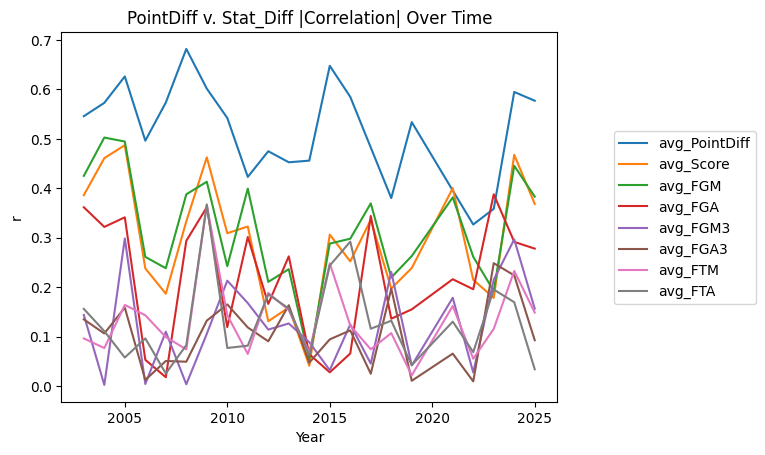

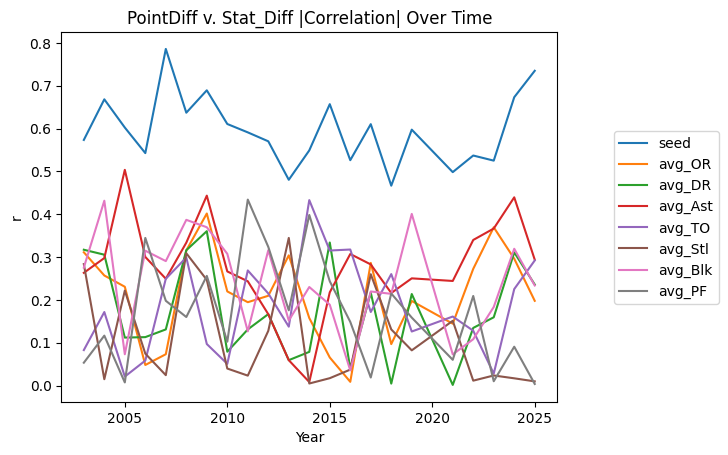

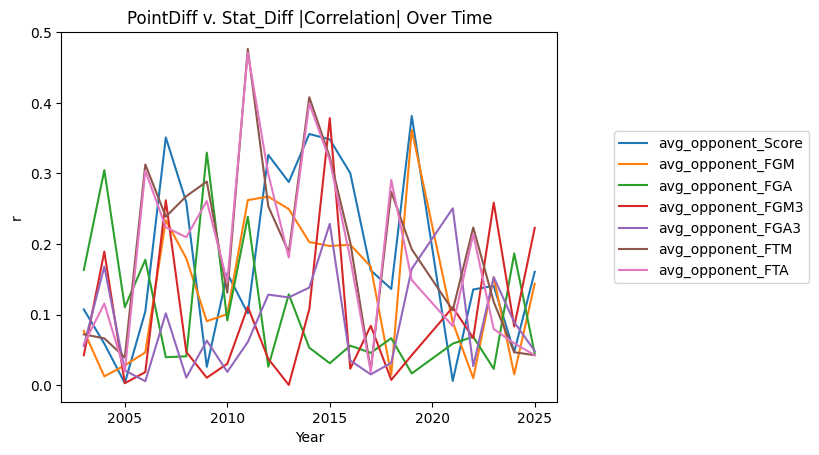

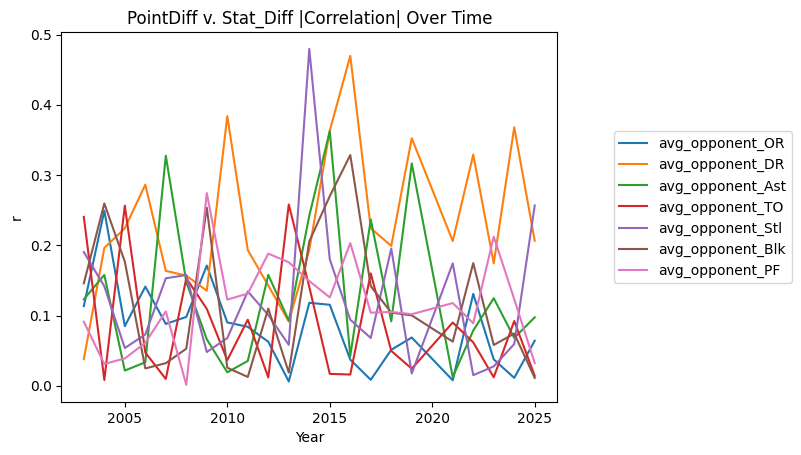

In [107]:
# Helper function that takes in a stat_name and start_year as input
# Plots and Displays Point Differential v. Raw Stat and Point Differential v. Stat Differential
def visualize_stat_correlation_over_time(stat_list):

    for stat_name in stat_list:

        years = list(range(2003, 2026))
        years.remove(2020)

        r_list = []

        for year in years:

            subset_tourney_data = M_tourney_data.loc[M_tourney_data["Season"] == year].copy()

            subset_tourney_data[f"{stat_name}_Diff"] = subset_tourney_data[f"T2_{stat_name}"] -  subset_tourney_data[f"T1_{stat_name}"]

            corr_diff_df = subset_tourney_data[["PointDiff", f"{stat_name}_Diff"]].copy()
            r_diff = corr_diff_df.corr().iloc[0,1]

            r_list.append(abs(r_diff))

        plt.plot(years, r_list, label = stat_name)
    
    plt.title(f"PointDiff v. Stat_Diff |Correlation| Over Time")
    plt.ylabel("r")
    plt.xlabel("Year")
    plt.legend(bbox_to_anchor = (1.1, 0.75))
    plt.show()


score_stats =  ["avg_PointDiff", 'avg_Score', "avg_FGM", "avg_FGA", "avg_FGM3", "avg_FGA3", 
            "avg_FTM", "avg_FTA"]

non_score_stats = ['seed', 'avg_OR', "avg_DR", "avg_Ast", "avg_TO", "avg_Stl", 
            "avg_Blk", "avg_PF"]

opp_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in score_stats[1:]]
opp_non_score_stats = [stat[:4] + "opponent_" + stat[4:] for stat in non_score_stats[1:]]

visualize_stat_correlation_over_time(score_stats)
visualize_stat_correlation_over_time(non_score_stats)
visualize_stat_correlation_over_time(opp_score_stats)
visualize_stat_correlation_over_time(opp_non_score_stats)

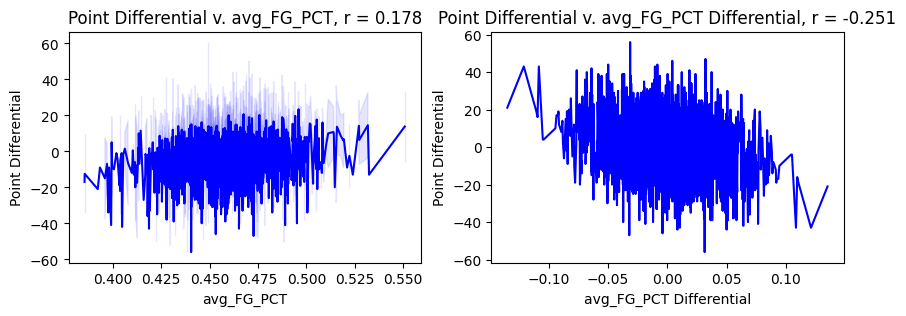

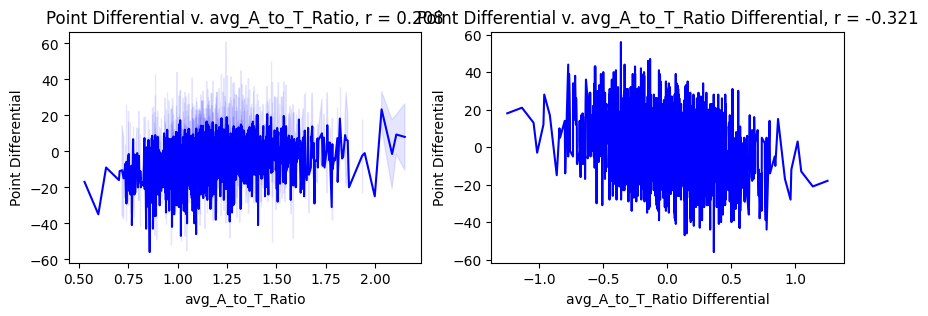

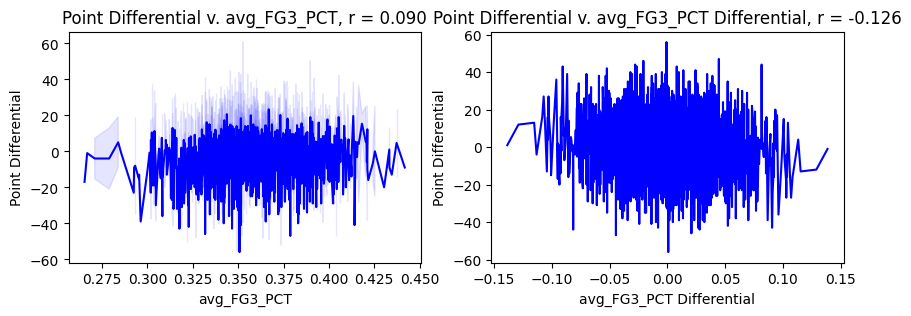

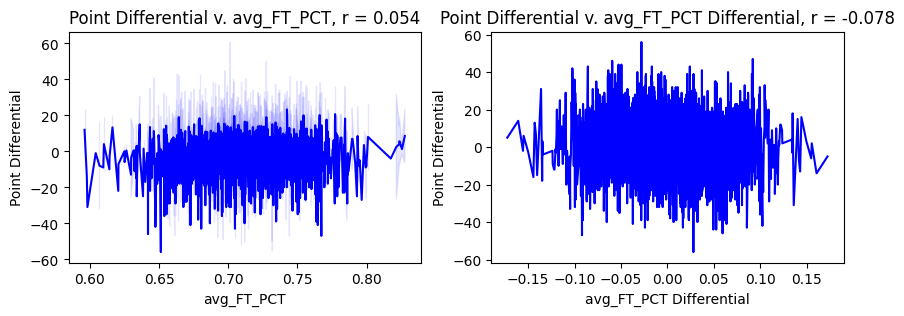

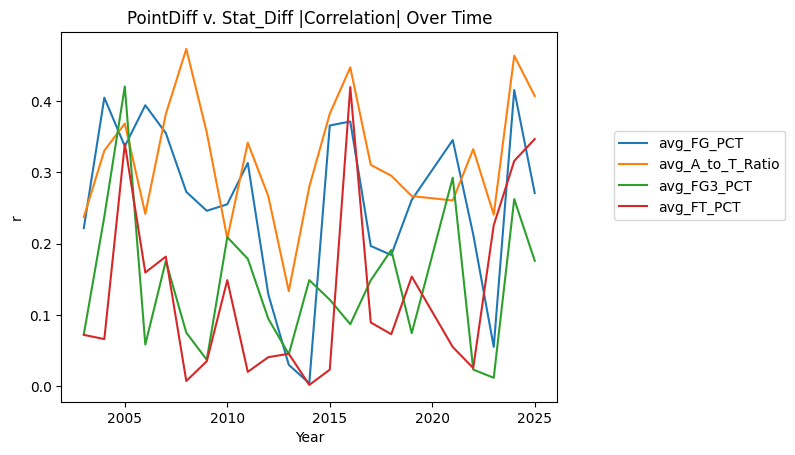

In [108]:
# try some derived metrics
M_tourney_data['T1_avg_FG_PCT'] = M_tourney_data['T1_avg_FGM'] / M_tourney_data['T1_avg_FGA']
M_tourney_data['T2_avg_FG_PCT'] = M_tourney_data['T2_avg_FGM'] / M_tourney_data['T2_avg_FGA']

M_tourney_data['T1_avg_FG3_PCT'] = M_tourney_data['T1_avg_FGM3'] / M_tourney_data['T1_avg_FGA3']
M_tourney_data['T2_avg_FG3_PCT'] = M_tourney_data['T2_avg_FGM3'] / M_tourney_data['T2_avg_FGA3']

M_tourney_data['T1_avg_FT_PCT'] = M_tourney_data['T1_avg_FTM'] / M_tourney_data['T1_avg_FTA']
M_tourney_data['T2_avg_FT_PCT'] = M_tourney_data['T2_avg_FTM'] / M_tourney_data['T2_avg_FTA']

M_tourney_data['T1_avg_A_to_T_Ratio'] = M_tourney_data['T1_avg_Ast'] / M_tourney_data['T1_avg_TO']
M_tourney_data['T2_avg_A_to_T_Ratio'] = M_tourney_data['T2_avg_Ast'] / M_tourney_data['T2_avg_TO']

advanced_stat_list = ['avg_FG_PCT', 'avg_A_to_T_Ratio', 'avg_FG3_PCT', 'avg_FT_PCT']

for advanced_stat in advanced_stat_list:
    visualize_stat_correlation(advanced_stat)

visualize_stat_correlation_over_time(advanced_stat_list)

In [ ]:
def run_pagerank(edge_weights, nodes, damping=0.85, max_iter=200, tol=1e-10):
    """
    edge_weights:
        dictionary where edge_weights[i][j] is the weight of the edge from team i to team j

    nodes:
        list or set of team ids in the season

    damping:
        probability of following edges. 0.85 is the common PageRank value.

    Returns:
        dictionary mapping TeamID -> PageRank score
    """

    nodes = list(nodes)
    n = len(nodes)

    if n == 0:
        return {}

    rank = {team: 1.0 / n for team in nodes}

    out_weight_sum = {}
    for team in nodes:
        out_weight_sum[team] = sum(edge_weights.get(team, {}).values())

    for _ in range(max_iter):
        new_rank = {team: (1.0 - damping) / n for team in nodes}

        dangling_rank = sum(rank[team] for team in nodes if out_weight_sum.get(team, 0) == 0)
        dangling_share = damping * dangling_rank / n

        for team in nodes:
            new_rank[team] += dangling_share

        for source_team in nodes:
            total_out = out_weight_sum.get(source_team, 0)

            if total_out == 0:
                continue

            for target_team, weight in edge_weights[source_team].items():
                transition_prob = weight / total_out
                new_rank[target_team] += damping * rank[source_team] * transition_prob
                
        diff = sum(abs(new_rank[team] - rank[team]) for team in nodes)
        rank = new_rank

        if diff < tol:
            break

    return rank

In [ ]:
def build_season_graph(results_df, season, recency_strength=0.25):
    """
    Builds a weighted directed graph for one college basketball season.

    Main idea:
        loser --> winner

    This means the losing team passes ranking credit to the team that beat them.
    The edge is stronger if:
        - the winner won by more points
        - the winner won on the road
        - the game happened later in the season
    """

    season_games = results_df.loc[results_df["Season"] == season].copy()

    edge_weights = defaultdict(lambda: defaultdict(float))

    teams = set(season_games["WTeamID"]).union(set(season_games["LTeamID"]))

    if season_games.empty:
        return edge_weights, teams

    max_day = season_games["DayNum"].max()

    for _, game in season_games.iterrows():
        winner = int(game["WTeamID"])
        loser = int(game["LTeamID"])

        winner_score = game["WScore"]
        loser_score = game["LScore"]

        margin = winner_score - loser_score
        total_points = winner_score + loser_score

        margin_weight = 1.0 + (margin / total_points)

        if game["WLoc"] == "A":
            location_weight = 1.15
        elif game["WLoc"] == "H":
            location_weight = 0.95
        else:
            location_weight = 1.00

        recency_weight = 1.0 + recency_strength * (game["DayNum"] / max_day)

        final_weight = margin_weight * location_weight * recency_weight

        edge_weights[loser][winner] += final_weight

    return edge_weights, teams

In [ ]:
def create_pagerank_features(results_df, damping=0.85):
    """
    Creates one PageRank rating per team per season.

    """

    all_rows = []

    for season in sorted(results_df["Season"].unique()):
        edge_weights, teams = build_season_graph(results_df, season)

        season_ranks = run_pagerank(
            edge_weights=edge_weights,
            nodes=teams,
            damping=damping
        )

        for team_id, score in season_ranks.items():
            all_rows.append({
                "Season": season,
                "TeamID": team_id,
                "pagerank": score
            })

    pagerank_df = pd.DataFrame(all_rows)

    pagerank_df["pagerank_rank"] = (
        pagerank_df
        .groupby("Season")["pagerank"]
        .rank(ascending=False, method="min")
    )

    return pagerank_df

In [112]:
M_pagerank = create_pagerank_features(M_regular_season_results)

M_pagerank.sort_values(
    ["Season", "pagerank"],
    ascending=[False, False]
).head(20)

,Season,TeamID,pagerank,pagerank_rank
8270,2026,1403,0.024784,1.0
7991,2026,1112,0.019911,2.0
8055,2026,1181,0.019699,3.0
8114,2026,1242,0.018569,4.0
8148,2026,1276,0.016164,5.0
8184,2026,1314,0.015415,6.0
8214,2026,1345,0.015141,7.0
8107,2026,1235,0.012860,8.0
8322,2026,1458,0.012530,9.0
8094,2026,1222,0.011929,10.0


In [113]:
M_teams = pd.read_csv("data/MTeams.csv")

M_pagerank_named = M_pagerank.merge(
    M_teams[["TeamID", "TeamName"]],
    on="TeamID",
    how="left"
)

M_pagerank_named.sort_values(
    ["Season", "pagerank"],
    ascending=[False, False]
).head(25)

,Season,TeamID,pagerank,pagerank_rank,TeamName
8270,2026,1403,0.024784,1.0,Texas Tech
7991,2026,1112,0.019911,2.0,Arizona
8055,2026,1181,0.019699,3.0,Duke
8114,2026,1242,0.018569,4.0,Kansas
8148,2026,1276,0.016164,5.0,Michigan
8184,2026,1314,0.015415,6.0,North Carolina
8214,2026,1345,0.015141,7.0,Purdue
8107,2026,1235,0.012860,8.0,Iowa St
8322,2026,1458,0.012530,9.0,Wisconsin
8094,2026,1222,0.011929,10.0,Houston


In [ ]:
def add_pagerank_to_matchups(matchup_df, pagerank_df):
    """
    Adds PageRank features for both teams in a tournament matchup.
    """

    t1_pr = pagerank_df.rename(columns={
        "TeamID": "T1_TeamID",
        "pagerank": "T1_pagerank",
        "pagerank_rank": "T1_pagerank_rank"
    })

    t2_pr = pagerank_df.rename(columns={
        "TeamID": "T2_TeamID",
        "pagerank": "T2_pagerank",
        "pagerank_rank": "T2_pagerank_rank"
    })

    matchup_df = matchup_df.merge(
        t1_pr[["Season", "T1_TeamID", "T1_pagerank", "T1_pagerank_rank"]],
        on=["Season", "T1_TeamID"],
        how="left"
    )

    matchup_df = matchup_df.merge(
        t2_pr[["Season", "T2_TeamID", "T2_pagerank", "T2_pagerank_rank"]],
        on=["Season", "T2_TeamID"],
        how="left"
    )

    matchup_df["pagerank_Diff"] = matchup_df["T1_pagerank"] - matchup_df["T2_pagerank"]

    matchup_df["pagerank_rank_Diff"] = matchup_df["T2_pagerank_rank"] - matchup_df["T1_pagerank_rank"]

    return matchup_df

In [115]:
M_tourney_data = add_pagerank_to_matchups(M_tourney_data, M_pagerank)

M_tourney_data[[
    "Season",
    "T1_TeamID",
    "T2_TeamID",
    "T1_pagerank",
    "T2_pagerank",
    "pagerank_Diff",
    "T1_pagerank_rank",
    "T2_pagerank_rank",
    "pagerank_rank_Diff",
    "PointDiff",
    "win"
]].head()

,Season,T1_TeamID,T2_TeamID,T1_pagerank,T2_pagerank,pagerank_Diff,T1_pagerank_rank,T2_pagerank_rank,pagerank_rank_Diff,PointDiff,win
0,2003,1421,1411,0.001342,0.001583,-0.000241,241.0,222.0,-19.0,7.111111,1
1,2003,1112,1436,0.010677,0.001949,0.008728,6.0,182.0,176.0,29.000000,1
2,2003,1113,1272,0.004870,0.009208,-0.004338,58.0,14.0,-44.0,13.000000,1
3,2003,1141,1166,0.004458,0.006415,-0.001957,66.0,38.0,-28.0,6.000000,1
4,2003,1143,1301,0.005375,0.007601,-0.002226,46.0,30.0,-16.0,1.777778,1


In [116]:
selected_features = ["T1_seed", 
                     "T2_seed", 
                     "seed_Diff", 
                     "T1_avg_Score", "T2_avg_Score",
                     "T1_avg_Blk", "T2_avg_Blk",
                     "T1_avg_PF", "T2_avg_PF",
                     "T1_avg_FGA", "T2_avg_FGA",
                     "T1_avg_opponent_FGM", "T2_avg_opponent_FGM",
                     "T1_avg_opponent_FGA", "T2_avg_opponent_FGA",
                     "T1_avg_opponent_Blk", "T2_avg_opponent_Blk",
                     "T1_avg_opponent_PF", "T2_avg_opponent_PF",
                     "T1_avg_PointDiff", "T2_avg_PointDiff"
                     ]

pagerank_features = [
    "T1_pagerank",
    "T2_pagerank",
    "pagerank_Diff",
    "T1_pagerank_rank",
    "T2_pagerank_rank",
    "pagerank_rank_Diff"
]

selected_features = selected_features + pagerank_features

# custom continous rating system + power rankings
# intangibles like injuries, coaching, and height
# Big question - Momentum?
# recent trends - statistic effectivness, shooting percentage
# Trapezoid of Excellence

print(f"Number of selected features: {len(selected_features)}")

Number of selected features: 27


In [117]:

# Specify hyperparameters for XGBoost

param = {
    "objective": "reg:squarederror",
    "booster" : "gbtree",
    "eta" : 0.01,
    "subsample" : 0.6,
    "colsample_bynode" : 0.8,
    "num_parallel_tree" : 2,
    "min_child_weight" : 4,
    "max_depth" : 4,
    "tree_method" : "hist",
    "grow_policy" : "lossguide",
    "max_bin" : 32
}

num_rounds = 700

In [118]:
# Training with holdout validation - predict one year's results based on all other years

models = {}

mask_mae = []
mask_preds = []
mask_targets = []
mask_ss = []

for mask_season in set(M_tourney_data.Season):
    x_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, selected_features].values
    y_train = M_tourney_data.loc[M_tourney_data["Season"] != mask_season, "PointDiff"].values

    x_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, selected_features].values
    y_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "PointDiff"].values
    season_validation = M_tourney_data.loc[M_tourney_data["Season"] == mask_season, "Season"].values

    dtrain = xgb.DMatrix(x_train, label=y_train)
    dvalidation = xgb.DMatrix(x_validation, label = y_validation)

    models[mask_season] = xgb.train(
        params = param,
        dtrain = dtrain,
        num_boost_round = num_rounds
    )

    preds = models[mask_season].predict(dvalidation)
    print(f"Mask Season: {mask_season} MAE: {mean_absolute_error(y_validation, preds)}")

    mask_mae.append(mean_absolute_error(y_validation, preds))
    mask_preds += list(preds)
    mask_targets += list(y_validation)
    mask_ss += list(season_validation)

print(f"Average MAE:  {np.mean(mask_mae)}")

# train on each respective year, get predicted outcome, then check against actual to see how much point diff was off

Mask Season: 2003 MAE: 8.801387509763138
Mask Season: 2004 MAE: 8.198722864523168
Mask Season: 2005 MAE: 7.456174211813616
Mask Season: 2006 MAE: 8.878049552637256
Mask Season: 2007 MAE: 7.715147142226083
Mask Season: 2008 MAE: 9.865057340473868
Mask Season: 2009 MAE: 9.16271063024437
Mask Season: 2010 MAE: 8.140496107781171
Mask Season: 2011 MAE: 9.102439006283308
Mask Season: 2012 MAE: 7.905242403286508
Mask Season: 2013 MAE: 10.886215840393731
Mask Season: 2014 MAE: 9.191243198212193
Mask Season: 2015 MAE: 7.296811675339332
Mask Season: 2016 MAE: 9.937957799087464
Mask Season: 2017 MAE: 7.684370028618013
Mask Season: 2018 MAE: 8.792160108444554
Mask Season: 2019 MAE: 9.726031761344638
Mask Season: 2021 MAE: 10.799230644686356
Mask Season: 2022 MAE: 10.343510516790387
Mask Season: 2023 MAE: 9.190426814890348
Mask Season: 2024 MAE: 10.491618933406338
Mask Season: 2025 MAE: 8.738762486923738
Average MAE:  9.013807571689526


<Axes: xlabel='pred_point_diff', ylabel='average_win_pct'>

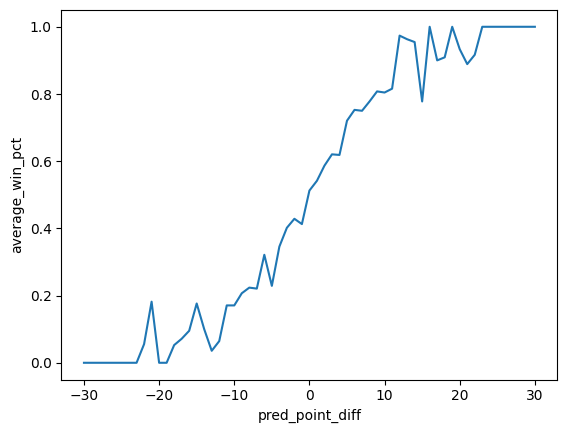

In [119]:
# Plot a graph of average win percentage vs. predicted point differential

df = pd.DataFrame({
    "Season" : mask_ss,
    "pred" : mask_preds,
    "label" : [(t > 0) for t in mask_targets]
})

df["pred_point_diff"] = df["pred"].astype(int)

xdf = df.clip(-30,30).groupby("pred_point_diff")["label"].mean().reset_index(name = "average_win_pct")

seaborn.lineplot(x = xdf["pred_point_diff"], y = xdf["average_win_pct"])

brier: 0.18713117110188257


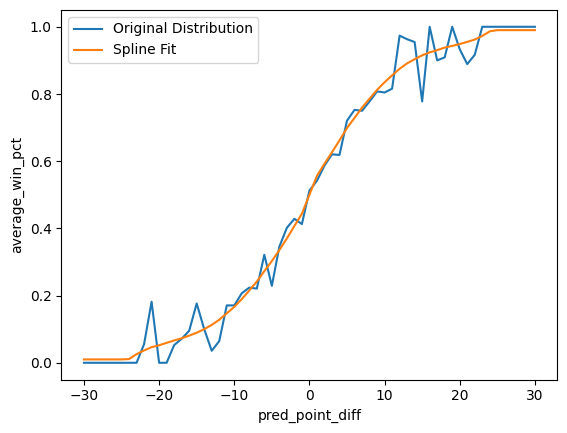

In [120]:
# Fit a Curve to the jagged data derived in the average win percentage vs pred point diff graph

t = 25
dat = list(zip(mask_preds, np.array(mask_targets) > 0))
dat = sorted(dat, key = lambda x:x[0])
pred, label = list(zip(*dat))
spline_model = UnivariateSpline(np.clip(pred, -t, t), label, k = 5)
spline_fit = np.clip(spline_model(np.clip(mask_preds, -t, t)), 0.01, 0.99)
print(f"brier: {brier_score_loss(np.array(mask_targets) > 0, spline_fit)}")
df["spline"] = spline_fit
xdf = df.clip(-30,30).groupby('pred_point_diff')[['spline', 'label']].mean().reset_index()

plt.figure()
plt.xlabel("pred_point_diff")
plt.ylabel('average_win_pct')
plt.plot(xdf['pred_point_diff'], xdf['label'])
plt.plot(xdf['pred_point_diff'], xdf['spline'])
plt.legend(['Original Distribution', 'Spline Fit'])

In [121]:
# For each season's tournament, compute and display the brier score
for mask_season in set(M_tourney_data.Season):
    x = df.loc[df["Season"] == mask_season, "spline"].values
    y = df.loc[df["Season"] == mask_season, "label"].values
    print(mask_season, np.round(brier_score_loss(y,x), 5))

2003 0.19474
2004 0.1823
2005 0.16808
2006 0.19513
2007 0.14251
2008 0.1633
2009 0.15562
2010 0.19592
2011 0.22599
2012 0.19411
2013 0.20054
2014 0.21336
2015 0.17013
2016 0.19082
2017 0.16359
2018 0.19334
2019 0.16619
2021 0.21458
2022 0.22953
2023 0.20711
2024 0.19338
2025 0.15258


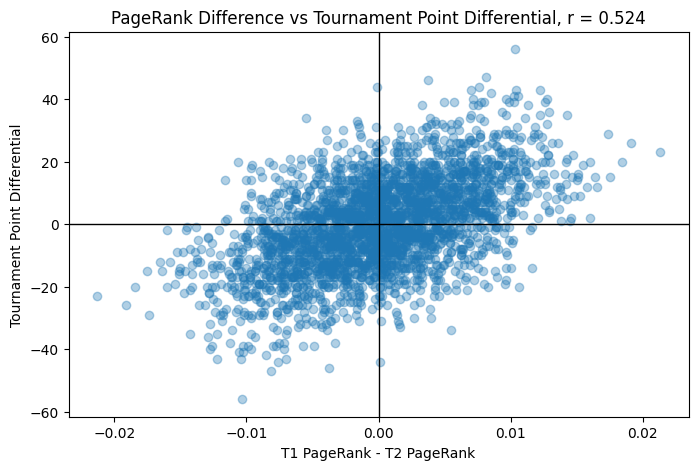

In [122]:
plt.figure(figsize=(8, 5))
plt.scatter(M_tourney_data["pagerank_Diff"], M_tourney_data["PointDiff"], alpha=0.35)

r = M_tourney_data[["pagerank_Diff", "PointDiff"]].corr().iloc[0, 1]

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"PageRank Difference vs Tournament Point Differential, r = {r:.3f}")
plt.xlabel("T1 PageRank - T2 PageRank")
plt.ylabel("Tournament Point Differential")
plt.show()

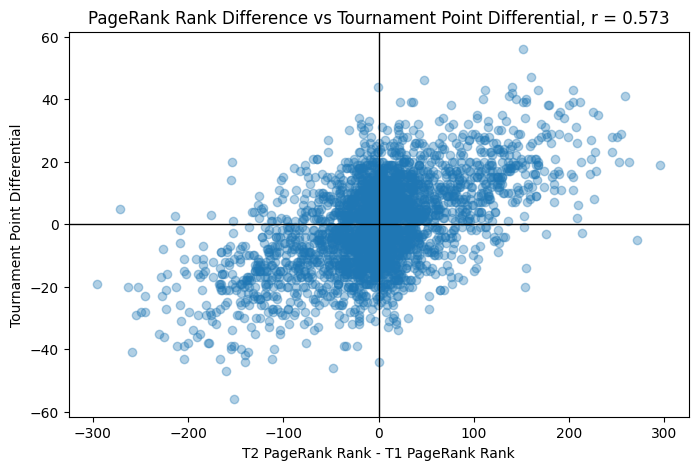

In [123]:
plt.figure(figsize=(8, 5))
plt.scatter(M_tourney_data["pagerank_rank_Diff"], M_tourney_data["PointDiff"], alpha=0.35)

r = M_tourney_data[["pagerank_rank_Diff", "PointDiff"]].corr().iloc[0, 1]

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"PageRank Rank Difference vs Tournament Point Differential, r = {r:.3f}")
plt.xlabel("T2 PageRank Rank - T1 PageRank Rank")
plt.ylabel("Tournament Point Differential")
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def plot_pagerank_network(season, results_df, pagerank_df, teams_df, top_n=15, min_edge_weight=1.5):
    """
    Visualize a directed graph of top teams in one season.

    """

    edge_weights, teams = build_season_graph(results_df, season)

    season_pr = pagerank_df.loc[pagerank_df["Season"] == season].copy()
    season_pr = season_pr.merge(
        teams_df[["TeamID", "TeamName"]],
        on="TeamID",
        how="left"
    )

    season_pr = season_pr.sort_values("pagerank", ascending=False).head(top_n)
    top_team_ids = set(season_pr["TeamID"])

    G = nx.DiGraph()

    for _, row in season_pr.iterrows():
        G.add_node(
            row["TeamID"],
            label=row["TeamName"],
            pagerank=row["pagerank"]
        )

    for source_team, targets in edge_weights.items():
        if source_team not in top_team_ids:
            continue

        for target_team, weight in targets.items():
            if target_team not in top_team_ids:
                continue
            if weight < min_edge_weight:
                continue

            G.add_edge(source_team, target_team, weight=weight)

    pos = nx.spring_layout(G, seed=42, k=1.2)

    node_sizes = []
    node_labels = {}
    for node in G.nodes():
        pr_value = G.nodes[node]["pagerank"]
        node_sizes.append(3000 + pr_value * 250000)
        node_labels[node] = G.nodes[node]["label"]

    edge_widths = []
    for u, v, data in G.edges(data=True):
        edge_widths.append(data["weight"] * 0.6)

    plt.figure(figsize=(14, 10))

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.85)
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9)
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="gray",
        arrows=True,
        arrowsize=18,
        width=edge_widths,
        alpha=0.55,
        connectionstyle="arc3,rad=0.08"
    )

    plt.title(f"Directed PageRank Network - Top {top_n} Teams ({season})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

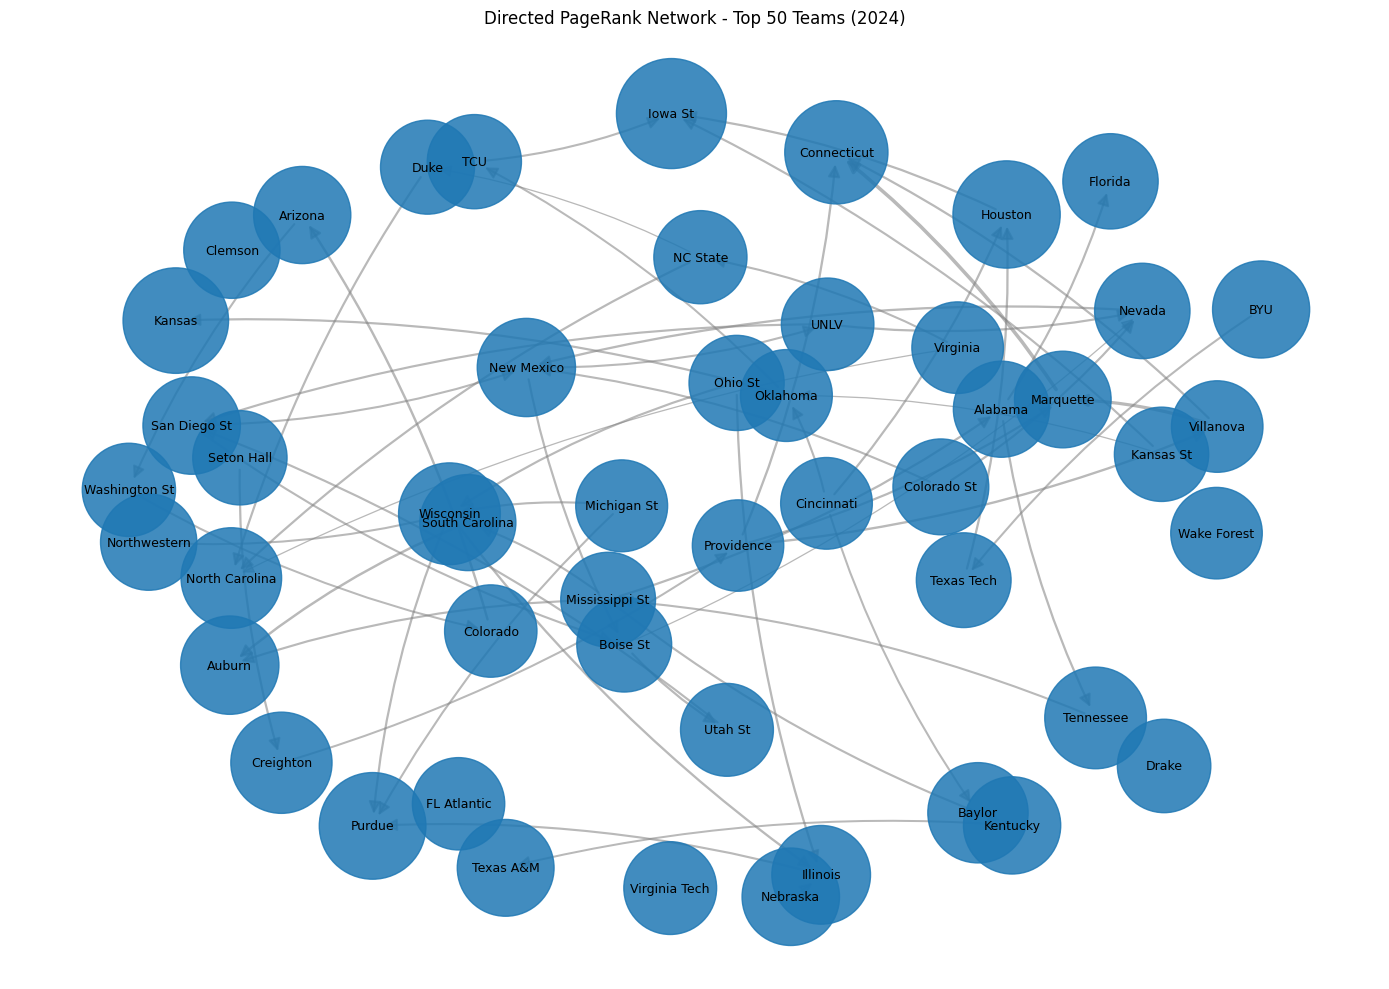

In [126]:
plot_pagerank_network(
    season=2024,
    results_df=M_regular_season_results,
    pagerank_df=M_pagerank,
    teams_df=M_teams,
    top_n=50,
    min_edge_weight=1.5
)

In [127]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_top_pagerank_bar(season, pagerank_df, teams_df, top_n=20):
    season_df = pagerank_df.loc[pagerank_df["Season"] == season].copy()

    season_df = season_df.merge(
        teams_df[["TeamID", "TeamName"]],
        on="TeamID",
        how="left"
    )

    season_df = season_df.sort_values("pagerank", ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    plt.barh(season_df["TeamName"][::-1], season_df["pagerank"][::-1])
    plt.xlabel("PageRank Score")
    plt.ylabel("Team")
    plt.title(f"Top {top_n} Teams by PageRank - {season}")
    plt.tight_layout()
    plt.show()

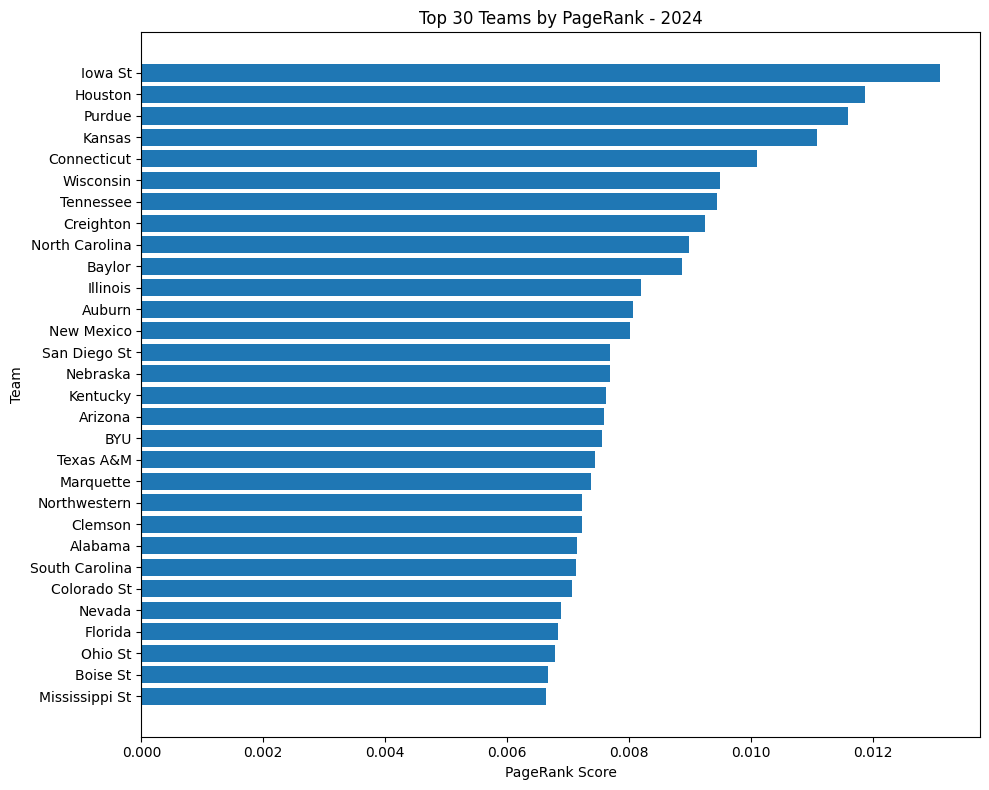

In [128]:
M_teams = pd.read_csv("data/MTeams.csv")
plot_top_pagerank_bar(2024, M_pagerank, M_teams, top_n=30)